# Lab 7- Data Analysis

Exercises 1-4 are to be completed by October 25th. The remaider of the lab is due November 1st. Before leaving lab today, everyone must download the dataset.

## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [1]:
!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  879M    0  879M    0     0  8322k      0 --:--:--  0:01:48 --:--:-- 6914k--  0:00:04 --:--:-- 28.0M   0 --:--:--  0:00:36 --:--:-- 8380k-  0:01:02 --:--:-- 3841k  9488k      0 --:--:--  0:01:03 --:--:-- 3333k--:--:--  0:01:08 --:--:-- 4464kk      0 --:--:--  0:01:22 --:--:-- 6746k      0 --:--:--  0:01:30 --:--:-- 10.0M-:--:--  0:01:31 --:--:-- 9675k01:40 --:--:-- 5977k


In [4]:
!rm SUSY.csv

In [5]:
!gunzip SUSY.csv.gz

In [6]:
ls -lh

total 5148104
-rw-r--r--@ 1 afarbin  staff   389K Oct 18 13:44 Lab.7.ipynb
-rw-r--r--@ 1 afarbin  staff   5.8M Oct 18 12:45 Lab.7.pdf
-rw-r--r--@ 1 afarbin  staff   228M Oct 18 12:39 SUSY-small.csv
-rw-r--r--  1 afarbin  staff   2.2G Oct 18 13:43 SUSY.csv


The data is provided as a comma separated file.

In [2]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [7]:
!ls -lh

total 5148104
-rw-r--r--@ 1 afarbin  staff   389K Oct 18 13:44 Lab.7.ipynb
-rw-r--r--@ 1 afarbin  staff   5.8M Oct 18 12:45 Lab.7.pdf
-rw-r--r--@ 1 afarbin  staff   228M Oct 18 12:39 SUSY-small.csv
-rw-r--r--  1 afarbin  staff   2.2G Oct 18 13:43 SUSY.csv


We see that we have 5 million datapoints.

In [5]:
!wc -l SUSY.csv

 5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [10]:
!head -500000 SUSY.csv > SUSY-small.csv

In [11]:
ls -lh

total 5173504
-rw-r--r--@ 1 afarbin  staff   387K Mar 29 11:08 Lab.7.ipynb
-rw-r--r--@ 1 afarbin  staff   6.1M Mar 18 10:38 Lab.7.pdf
-rw-r--r--@ 1 afarbin  staff   228M Mar 29 11:09 SUSY-small.csv
-rw-r--r--@ 1 afarbin  staff   2.2G Mar 18 10:38 SUSY.csv


In [12]:
! wc -l SUSY-small.csv

  500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [6]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [7]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [8]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [9]:
FeatureNames

['R',
 'axial_MET',
 'M_R',
 'dPhi_r_b',
 'cos_theta_r1',
 'M_TR_2',
 'S_R',
 'M_Delta_R',
 'MT2',
 'MET_rel']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [11]:
filename = "SUSY-small.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [12]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,0.0,0.719035,1.091879,0.291540,1.205962,-1.599117,-1.139445,0.424546,1.154849,0.637185,-0.091178,1.972156,0.697028,0.313636,0.988602,1.981573,0.744828,1.095080,0.006546
499996,1.0,0.910016,-0.364544,-0.777120,0.543648,-0.910632,-1.723707,2.864673,1.458272,2.176558,-0.590911,0.673695,1.662140,2.189362,1.195041,0.910815,1.181893,1.252362,0.826035
499997,1.0,0.842954,0.332476,-1.048564,1.347989,0.320496,-0.666358,0.450433,-0.411872,0.293407,0.630491,0.859920,0.403371,0.416258,0.591989,0.372003,0.716788,0.366991,0.265798
499998,0.0,1.370760,-1.162912,0.893499,2.118091,1.248496,-0.887211,0.164659,0.316840,0.215165,0.280418,3.087083,0.526929,0.151467,0.308067,3.098183,0.233042,0.876216,0.000593


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [13]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


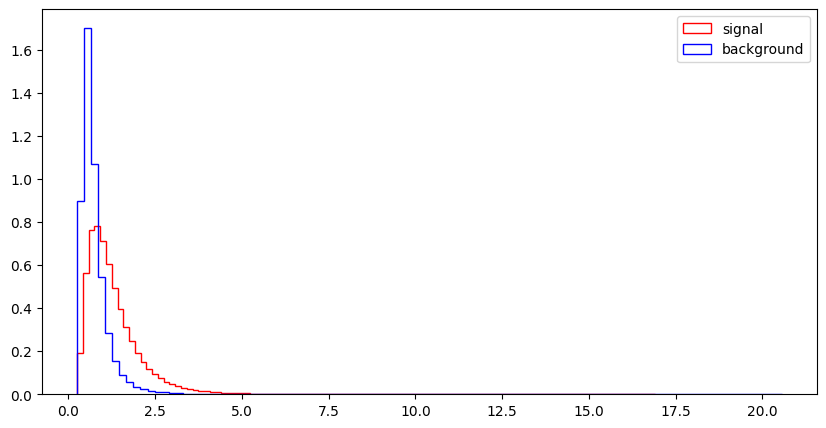

l_1_eta


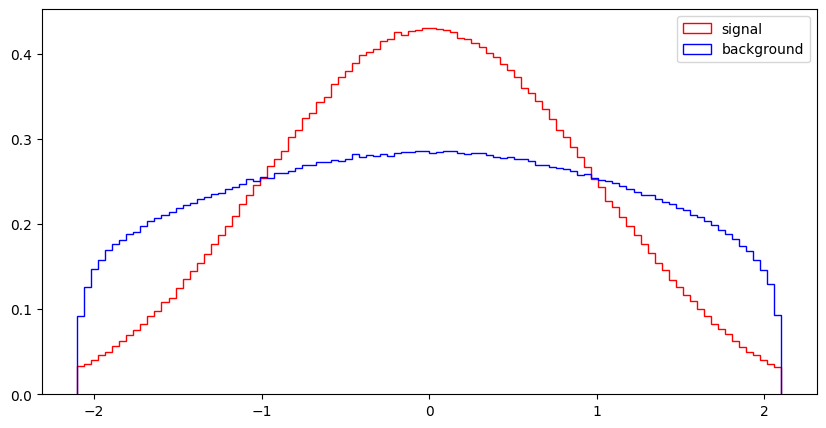

l_1_phi


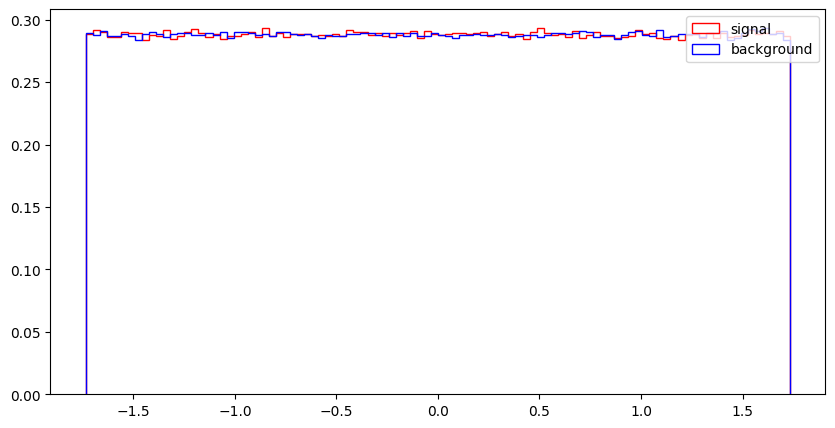

l_2_pT


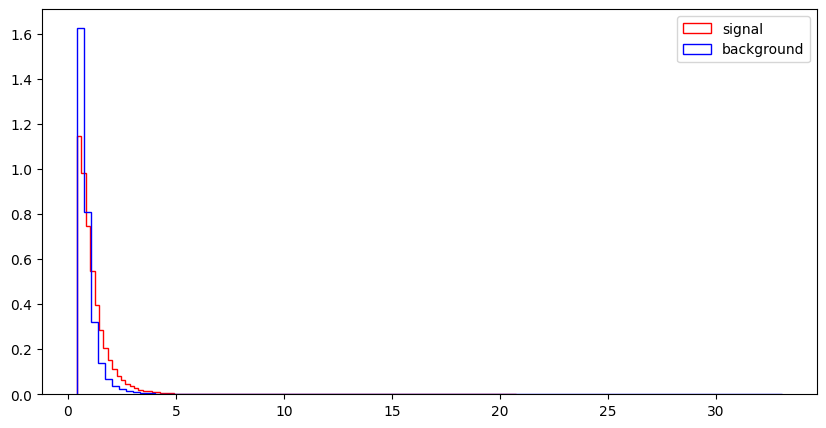

l_2_eta


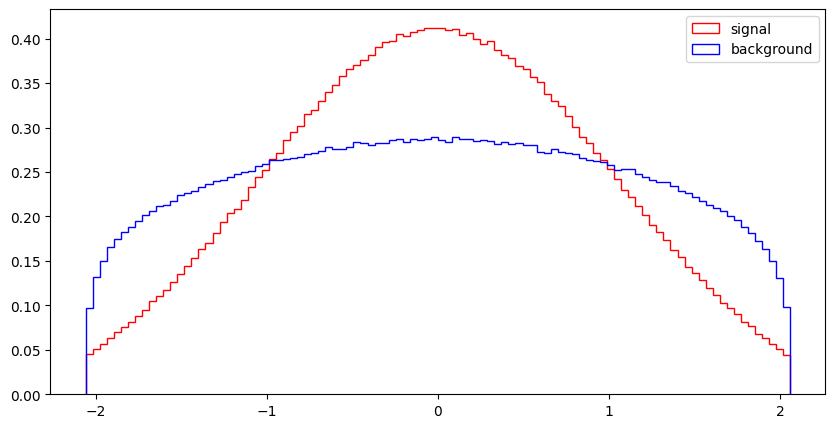

l_2_phi


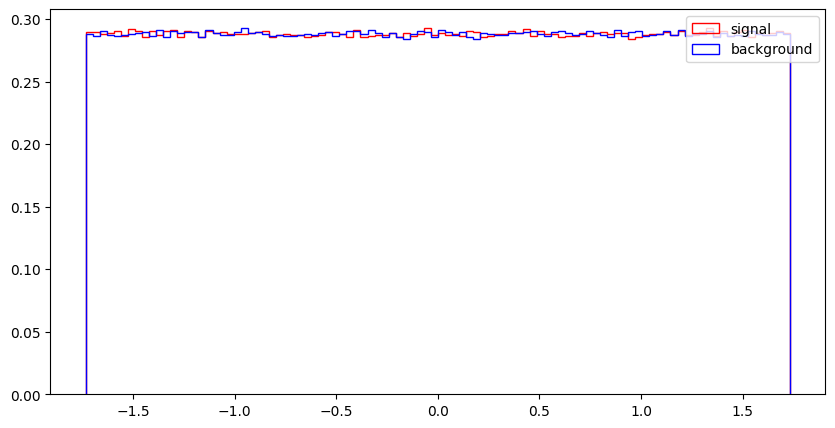

MET


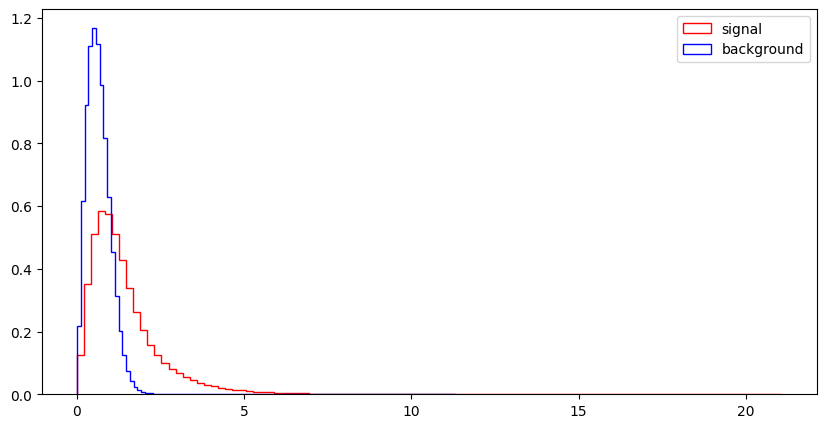

MET_phi


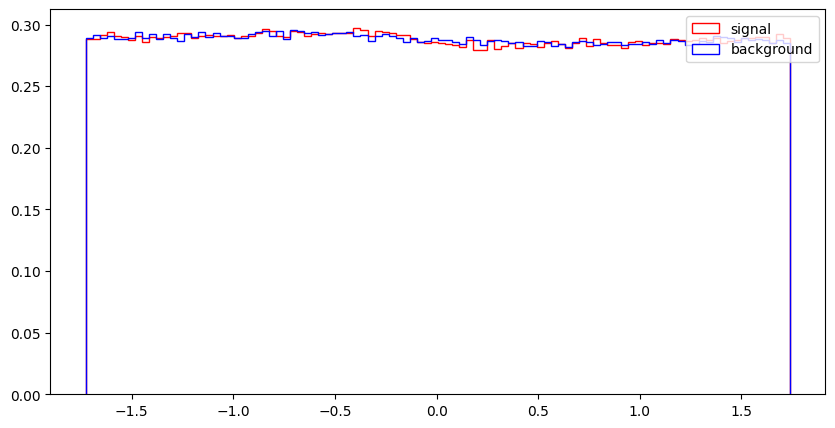

MET_rel


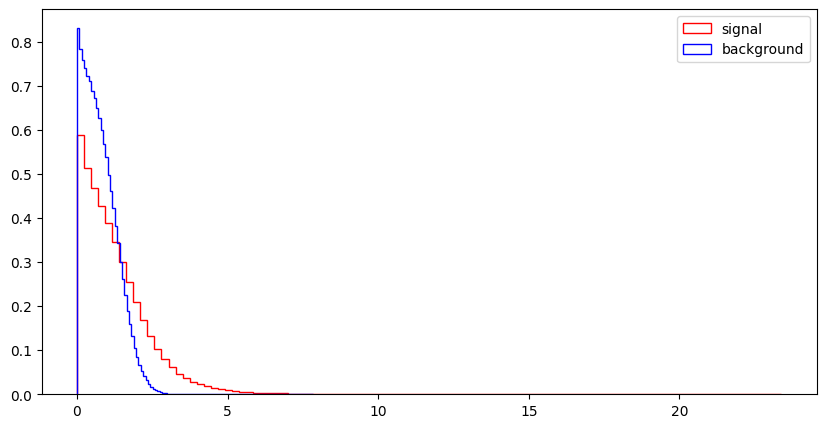

axial_MET


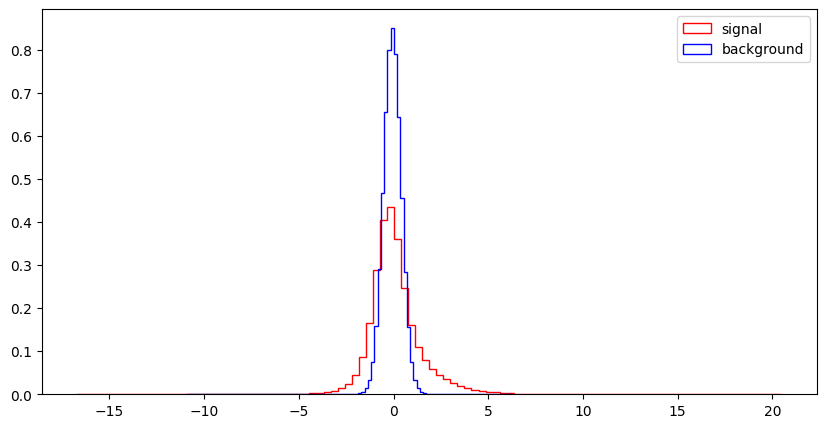

M_R


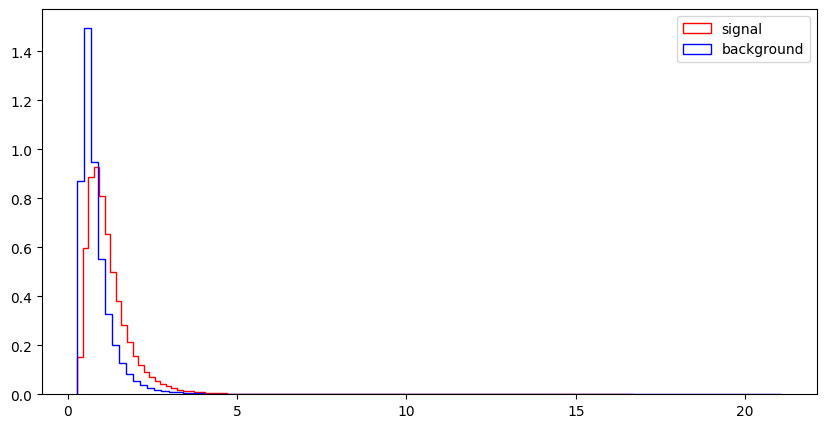

M_TR_2


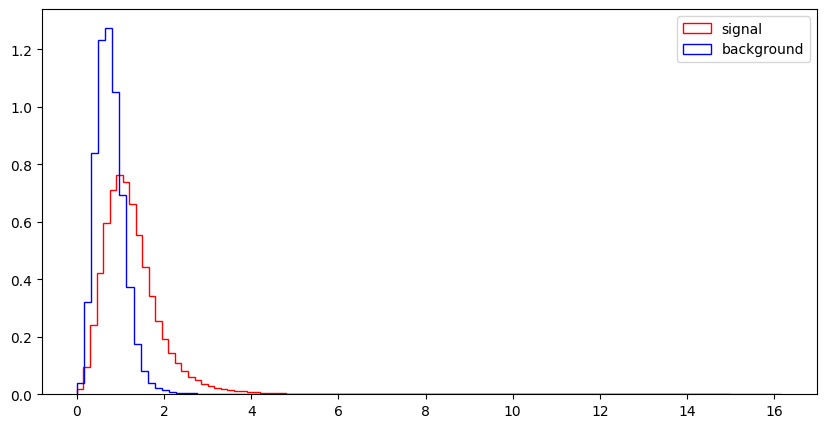

R


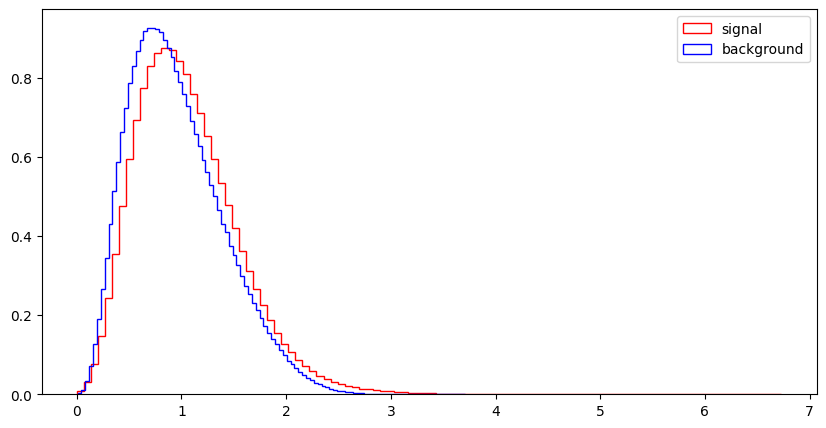

MT2


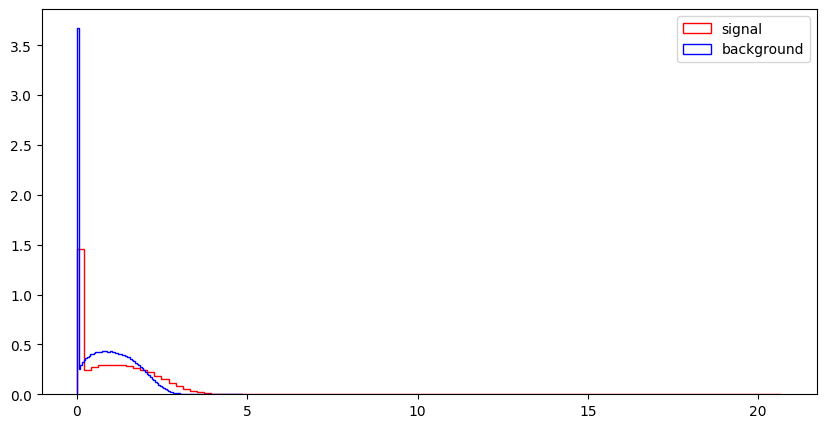

S_R


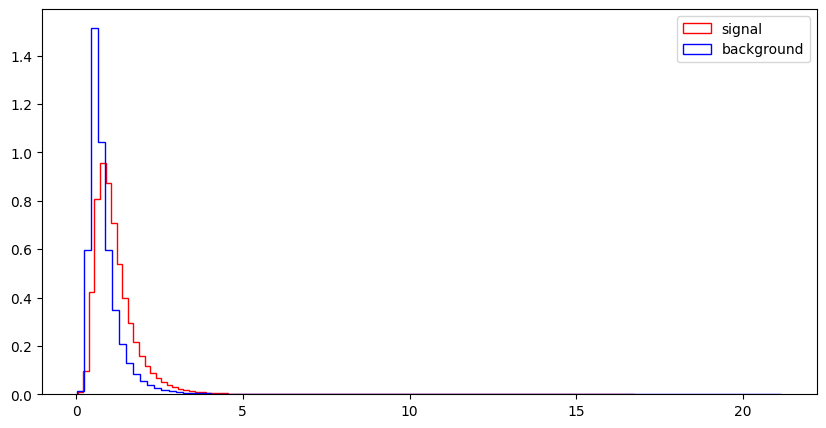

M_Delta_R


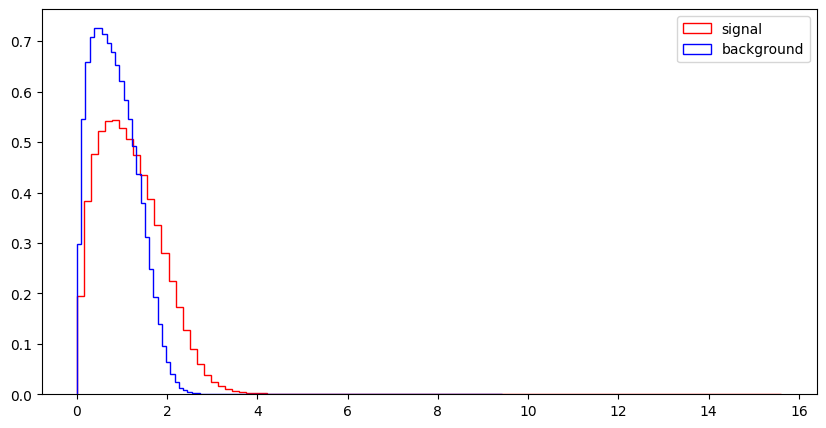

dPhi_r_b


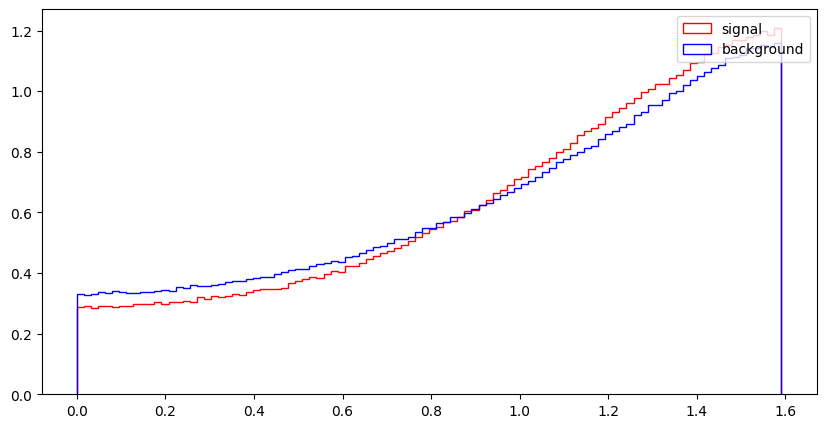

cos_theta_r1


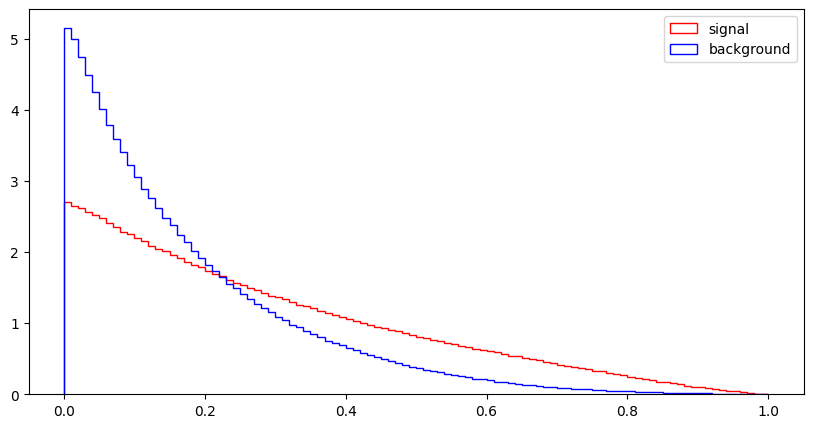

In [13]:
# Professor's code and output (did not run this in my notebook)
#import numpy as np
#for var in VarNames[1:]:
    #print (var)
    #plt.figure(figsize=(10,5))
    #plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    #plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    #plt.legend(loc='upper right')
    #plt.show()

l_1_pT


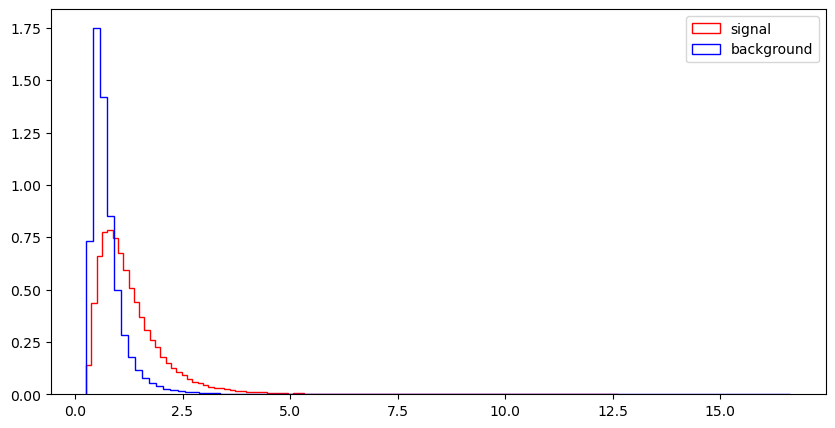

l_1_eta


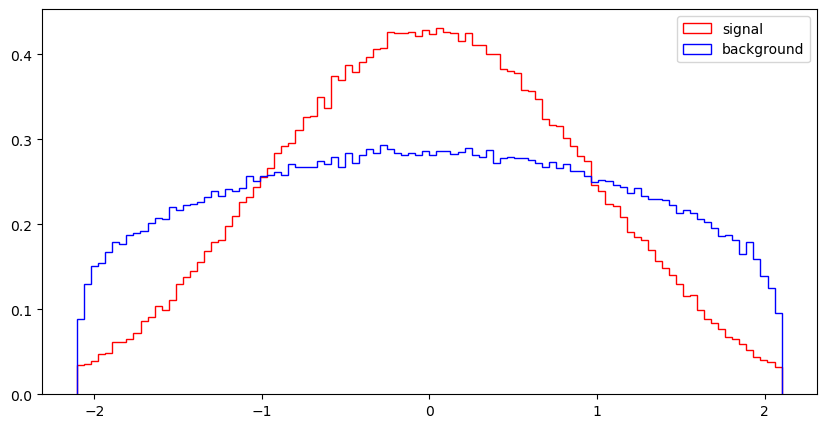

l_1_phi


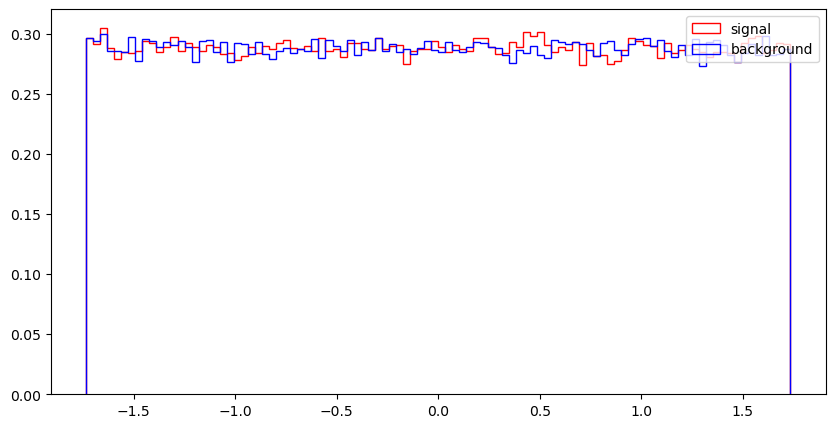

l_2_pT


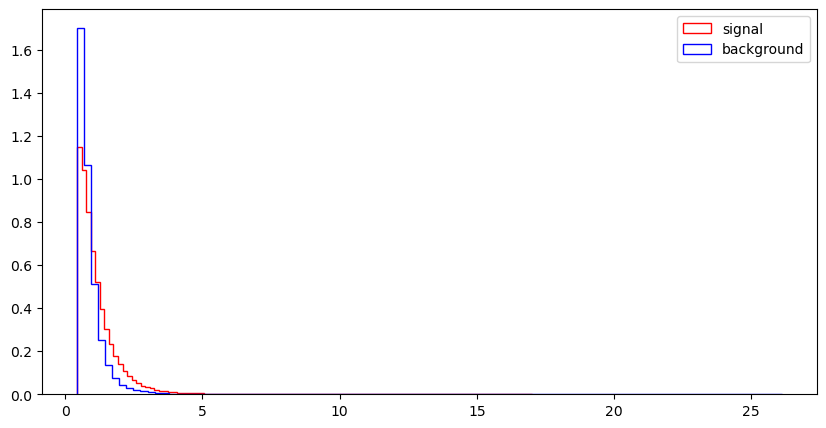

l_2_eta


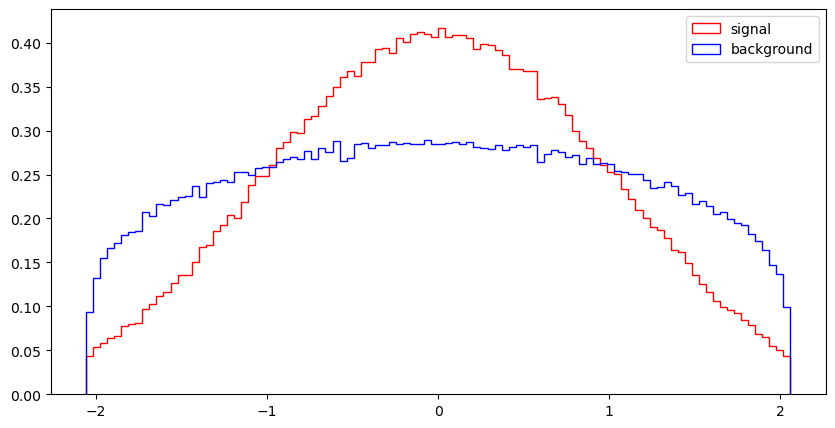

l_2_phi


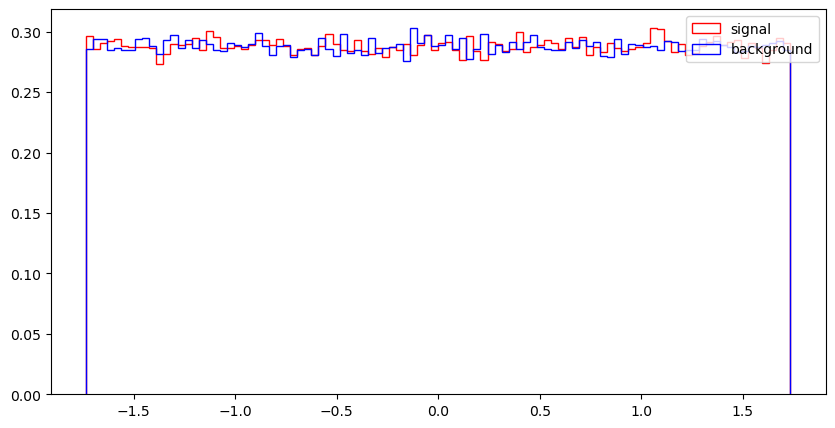

MET


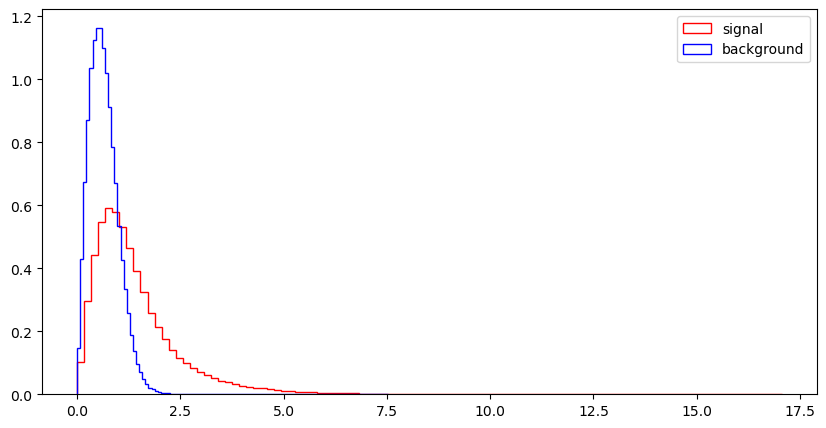

MET_phi


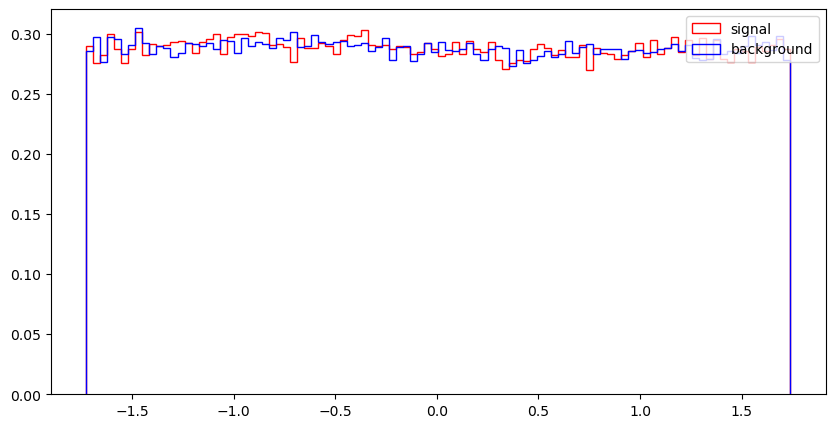

MET_rel


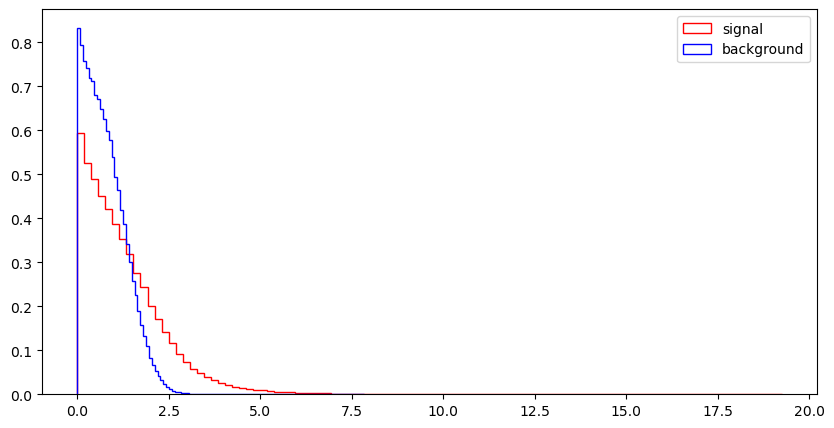

axial_MET


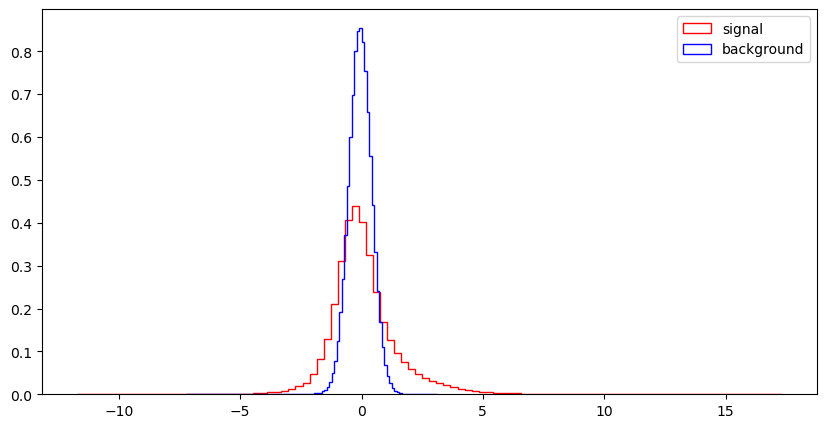

M_R


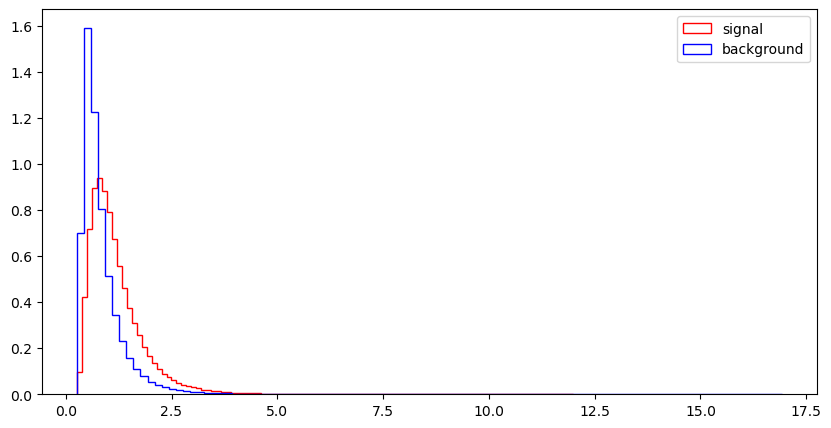

M_TR_2


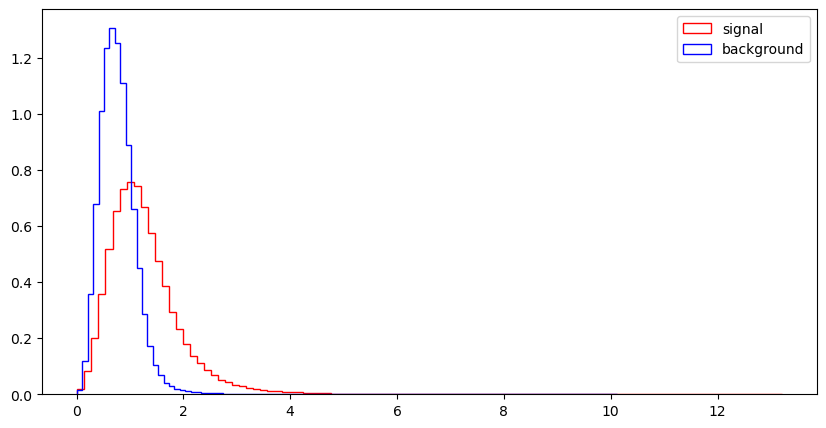

R


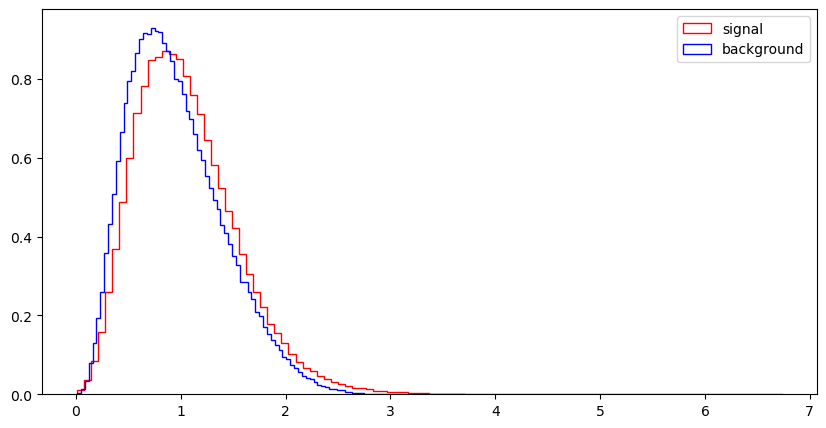

MT2


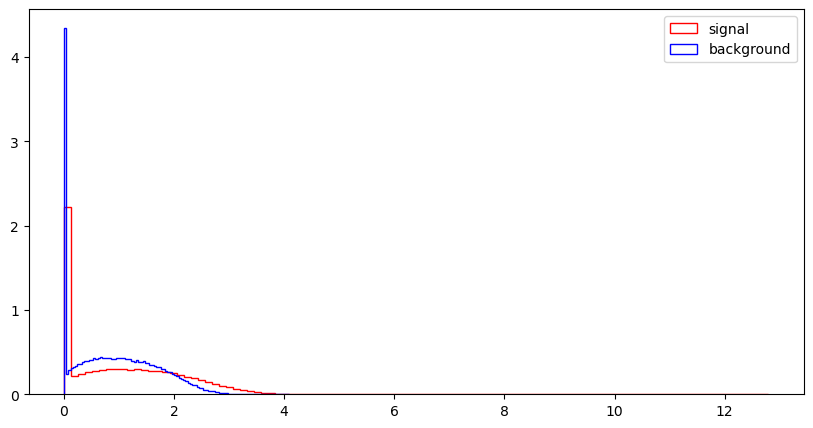

S_R


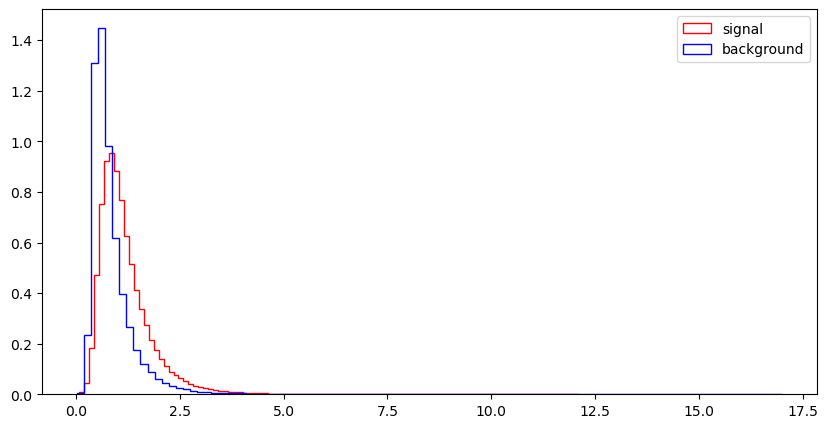

M_Delta_R


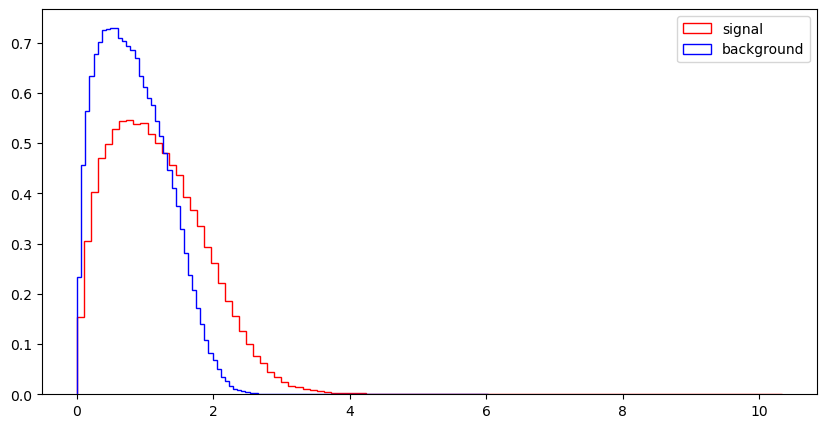

dPhi_r_b


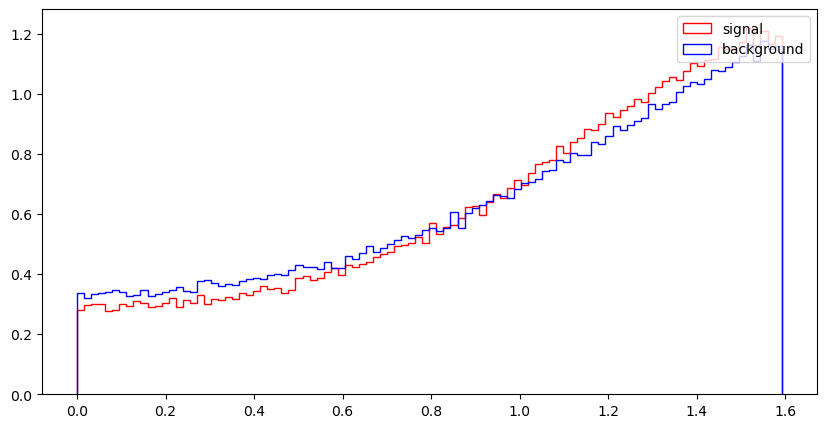

cos_theta_r1


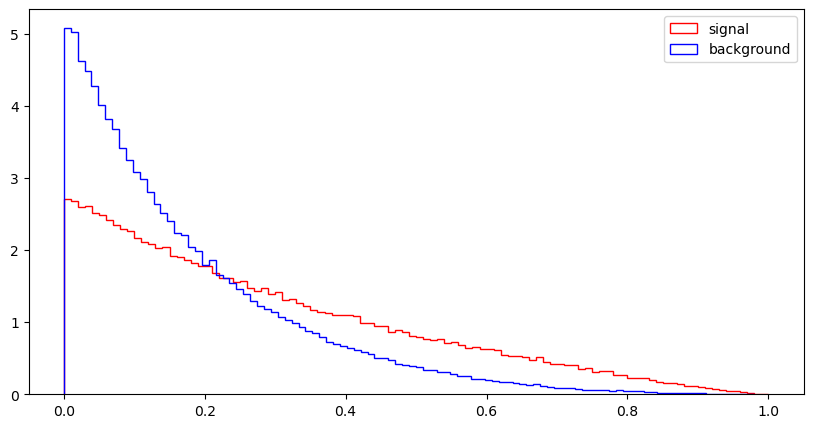

In [26]:
# my code and output (recreating the graphs shown by Dr Farbin's code)
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

In [21]:
signal_df = df[df["signal"] == 1]
background_df = df[df["signal"] == 0]


def plot_feature_histograms(signal_df, background_df, cols, title=""):
    """
    signal_df: rows where signal = 1
    background_df: rows where signal = 0
    cols: list of variables to plot
    """
    
    n = len(cols)
    
    # Decide grid size (like paper layout)
    n_cols = 3
    n_rows = (n + n_cols - 1) // n_cols  # round up
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows))
    fig.suptitle(title, fontsize=16)
    
    axes = axes.flatten()  # make indexing easier
    
    # Step 3: Loop through variables\
    for i, col in enumerate(cols):
        ax = axes[i]
        
        # Plot signal (black)
        ax.hist(signal_df[col],
                bins=40,
                density=True,   # makes it "fraction of events"
                histtype='step',
                color='black',
                label='Signal')
        
        # Plot background (red)
        ax.hist(background_df[col],
                bins=40,
                density=True,
                histtype='step',
                color='red',
                label='Background')
        
        ax.set_title(col, fontsize=10)
        ax.set_xlabel(col)
        ax.set_ylabel("Fraction of Events")
        
        ax.legend(fontsize=8)
    
    # Turn off extra empty plots
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

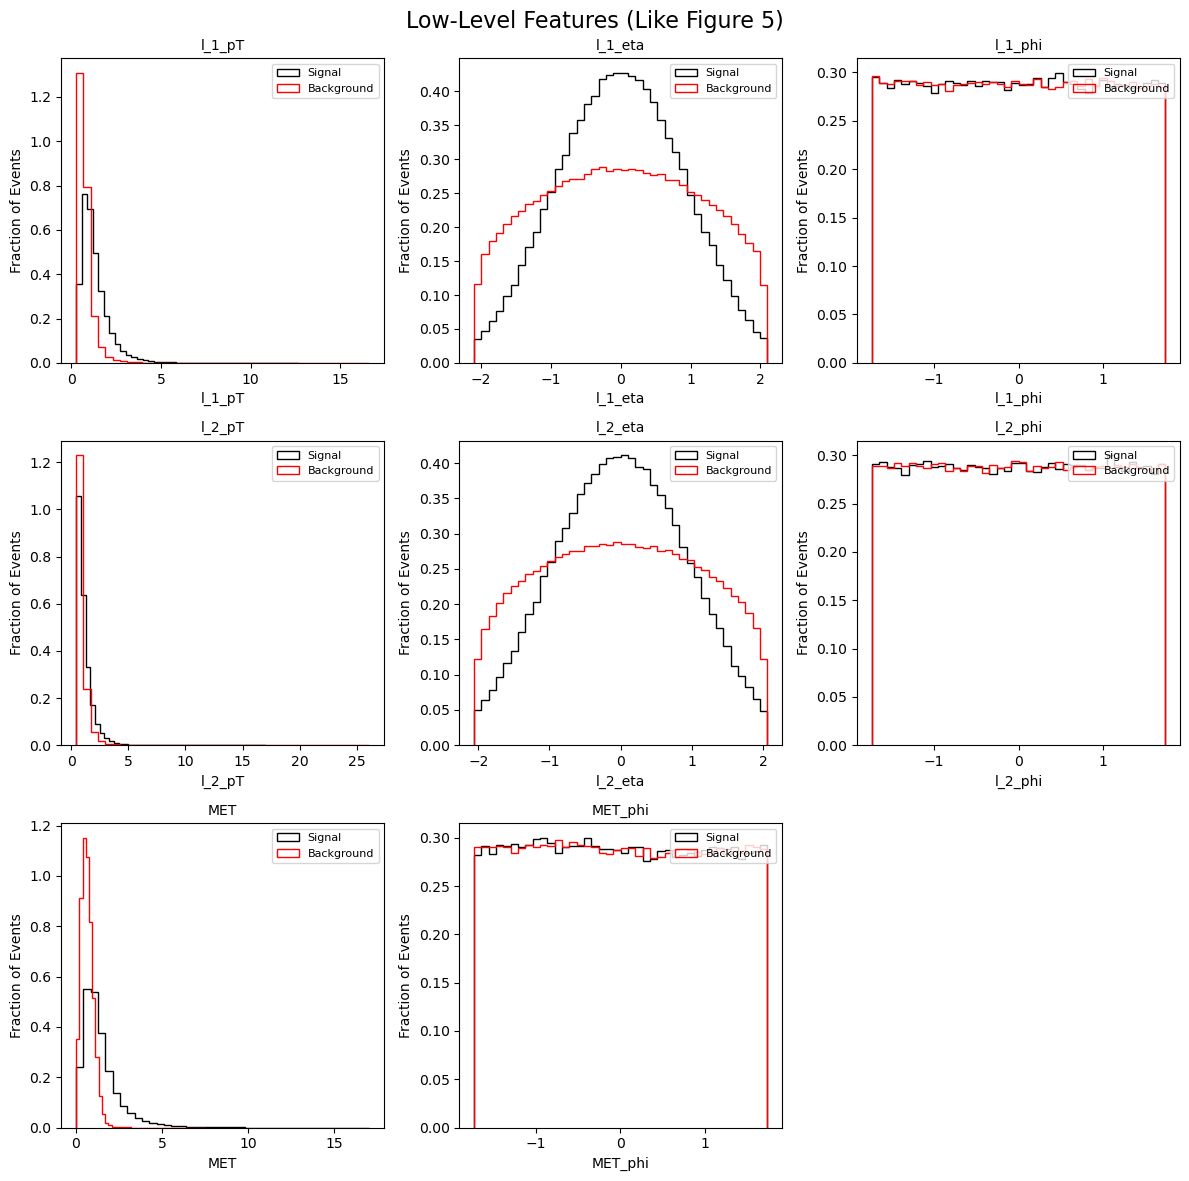

In [22]:
#Figure 5
plot_feature_histograms(signal_df, background_df, RawNames, title="Low-Level Features (Like Figure 5)")

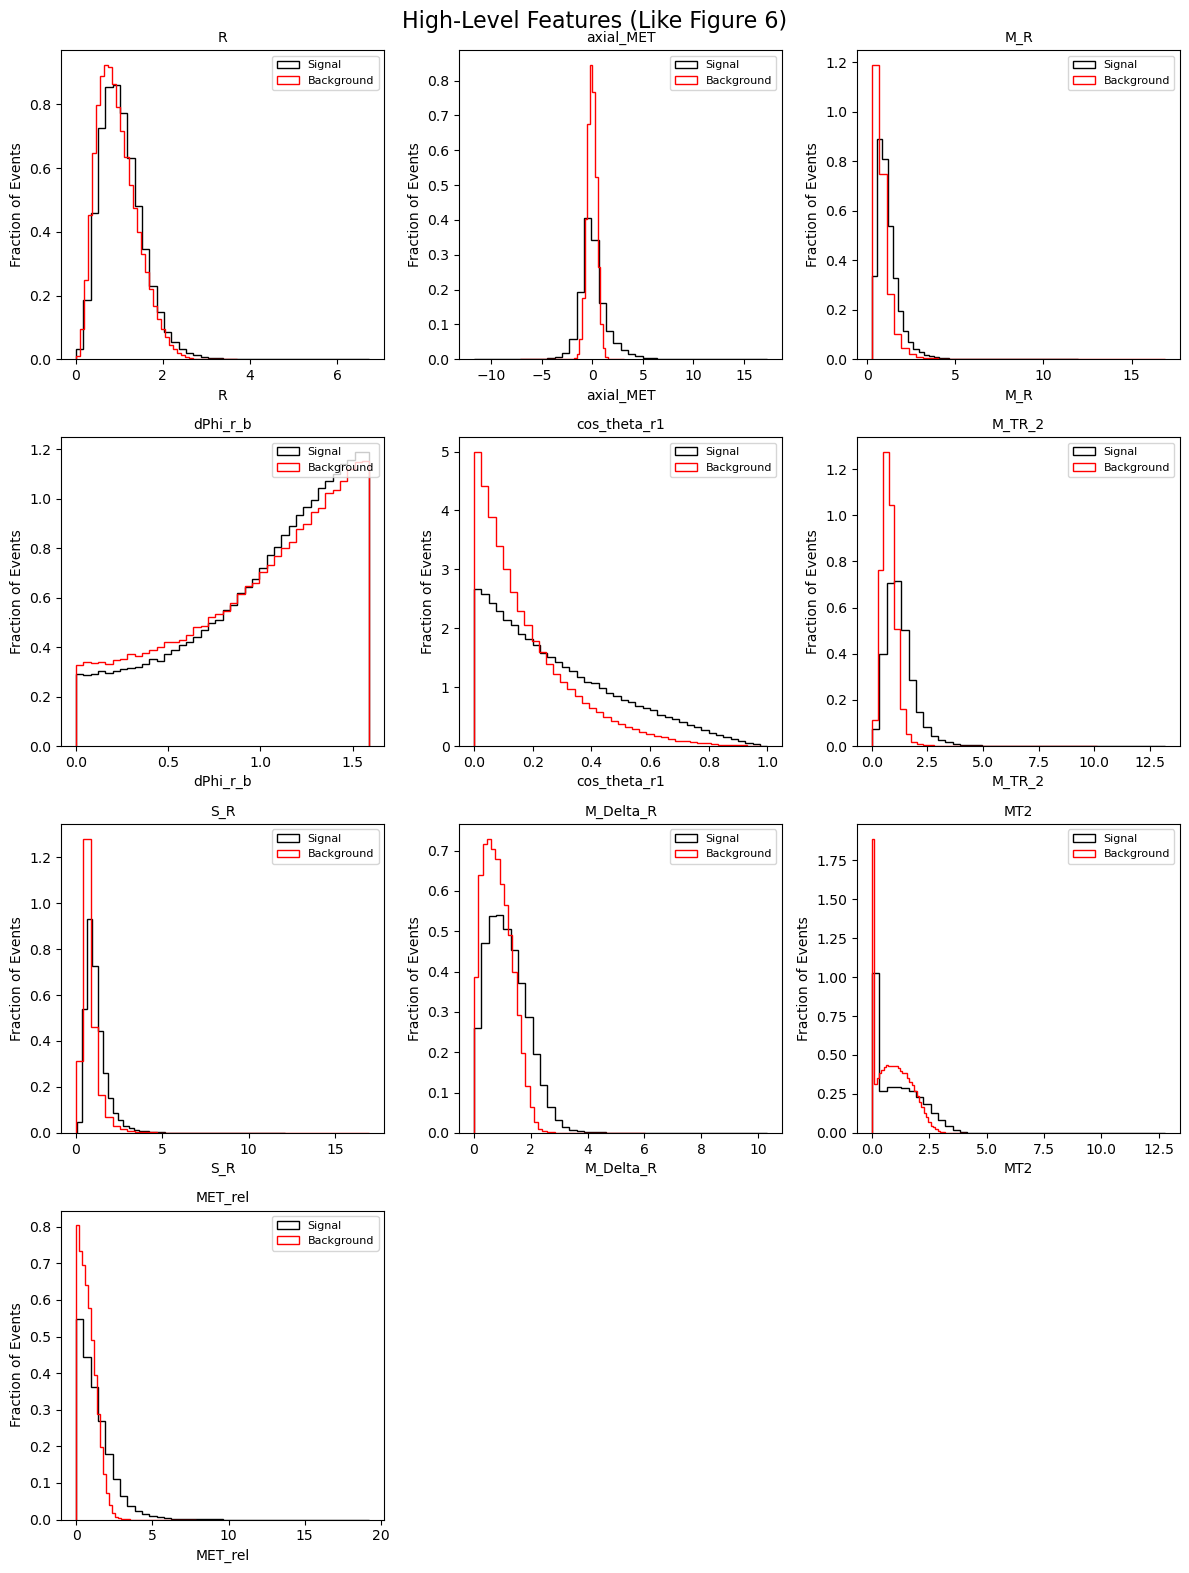

In [23]:
# Figure 6
plot_feature_histograms(signal_df, background_df, FeatureNames, title="High-Level Features (Like Figure 6)")

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

In [14]:
# Part a: Function to make a pair plot
def pair_plot(df, cols, title=""):
    n = len(cols)  # How many variables we are plotting
    fig, axes = plt.subplots(n, n, figsize=(12,12))  # Make a grid of plots
    
    # Add an overall title
    fig.suptitle(title, fontsize=16, y=0.92)
    
    # Loop over all rows and columns of the grid
    for i in range(n):
        for j in range(n):
            ax = axes[i, j]  # Select the subplot at row i, column j
            
            if i == j:
                # Diagonal: plot a histogram of the variable
                ax.hist(df[cols[i]], bins=30, color='skyblue', edgecolor='black')
            else:
                # Off-diagonal: scatter plot of variable i vs variable j
                ax.scatter(df[cols[j]], df[cols[i]], s=5, alpha=0.5)
            
            # Make the plot look nicer by hiding some labels
            if i < n-1:
                ax.set_xticks([])  # Only show x labels on bottom row
            else:
                ax.set_xlabel(cols[j], fontsize=8, rotation=45)
                
            if j > 0:
                ax.set_yticks([])  # Only show y labels on first column
            else:
                ax.set_ylabel(cols[i], fontsize=8)
    
    plt.tight_layout()  
    plt.show()        

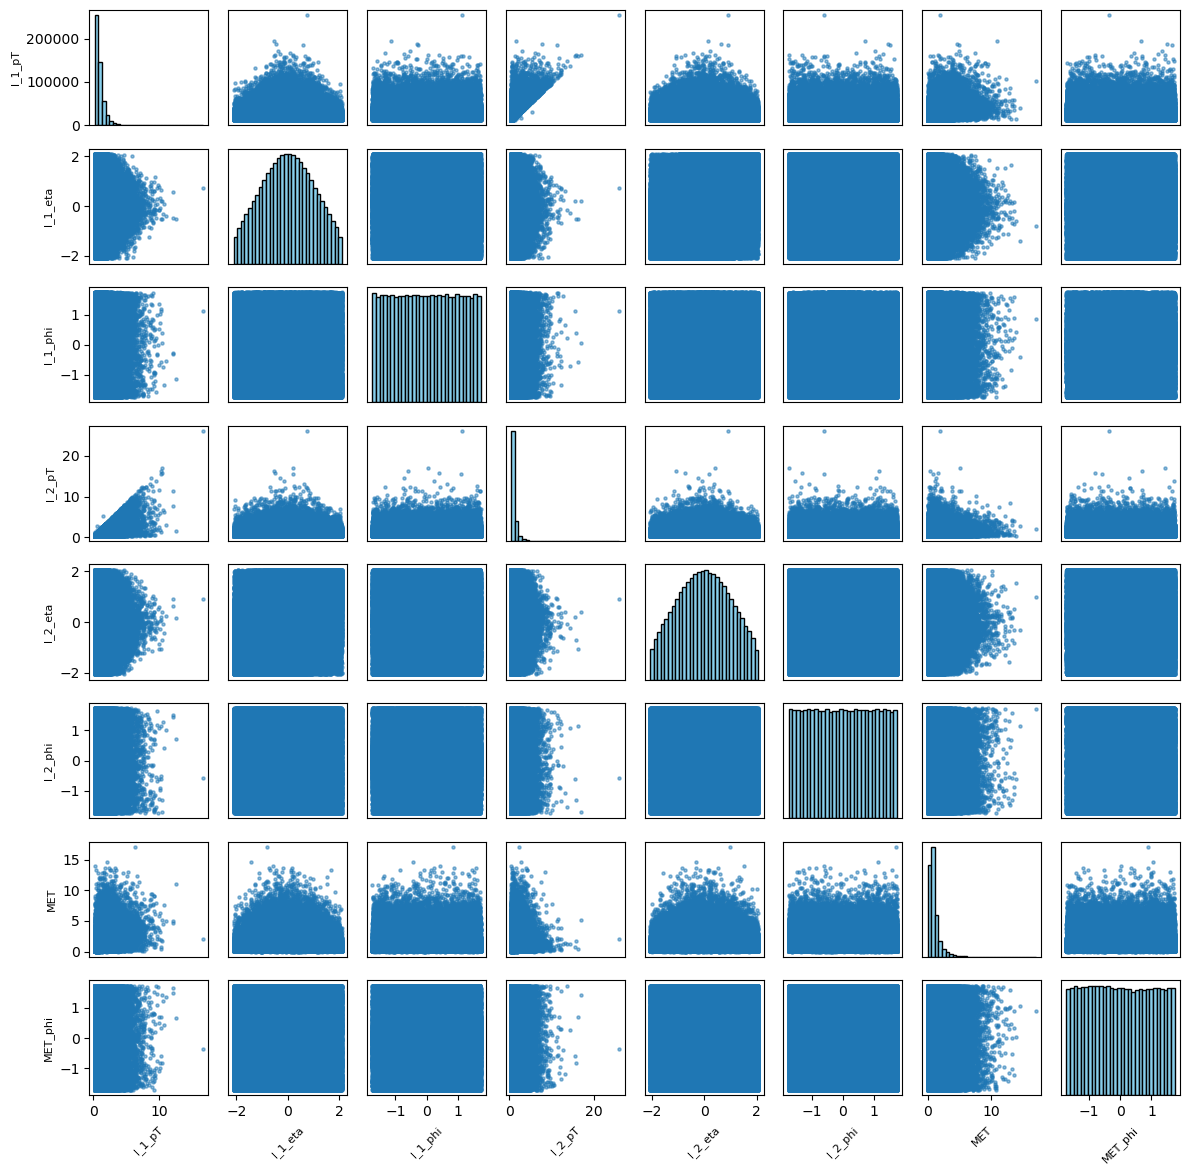

In [15]:
# Making pair plots for low-level (raw) features
pair_plot(df, RawNames)

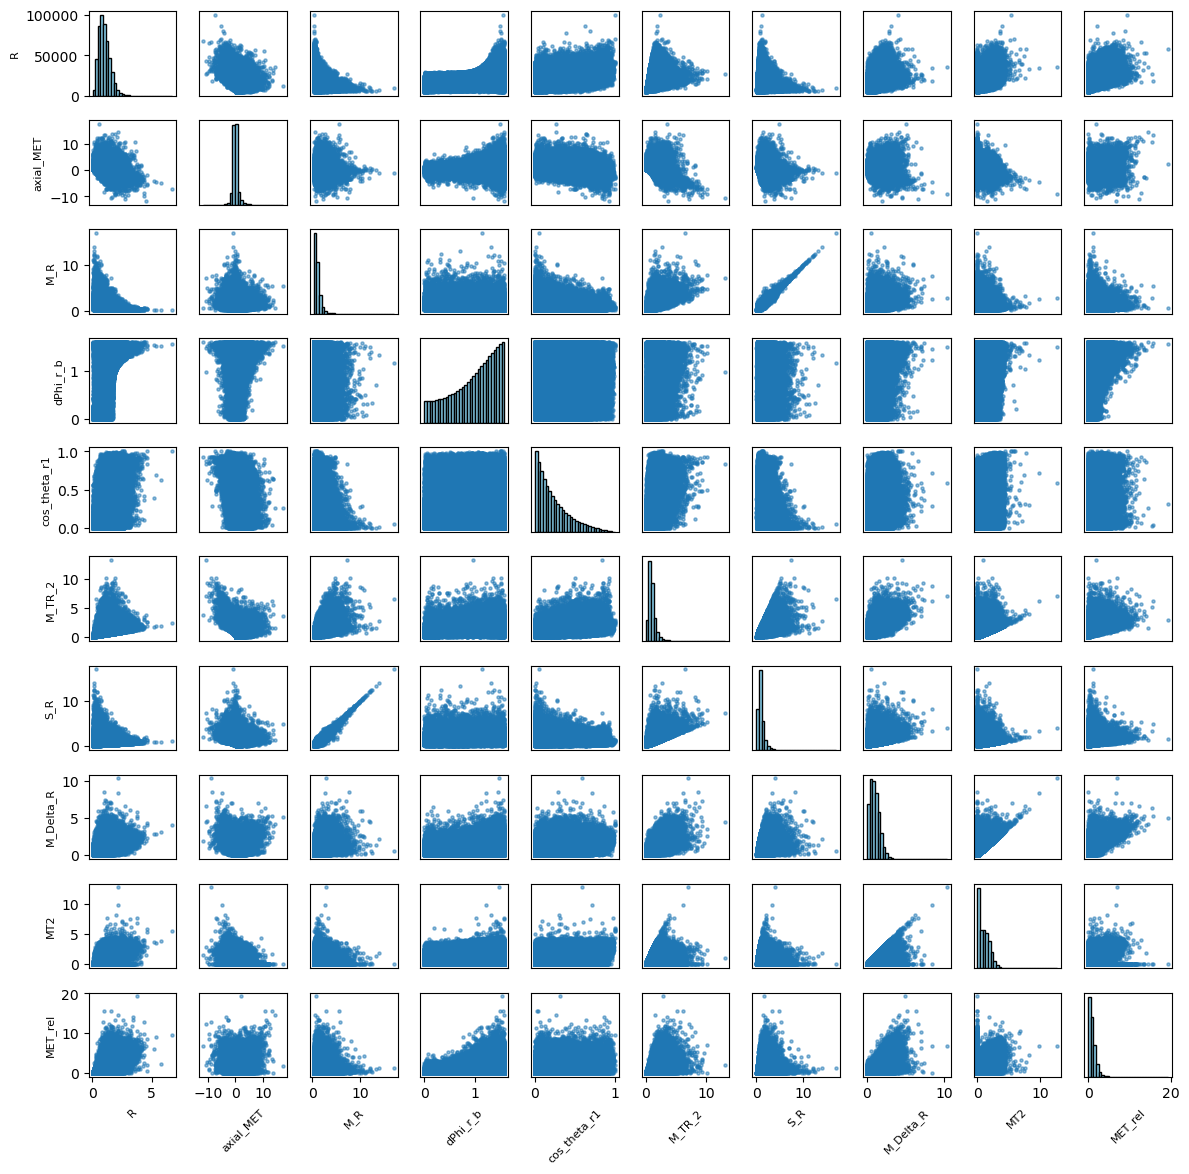

In [16]:
# Make pair plots for high-level (derived) features
pair_plot(df, FeatureNames)

### Part b: Speeding up the function
I asked Chat GPT for a list of ways we can make the pair plot function run faster:

Of course! Here’s a small, clean list of simple ways to make your pair plot faster:

⚡ Simple ways to speed up pair plots
1. Use a smaller sample of the data

Instead of plotting every row, randomly pick a subset.

👉 Why it helps: fewer points = faster plotting

df = df.sample(1000)
2. Plot only half the matrix (triangle method)

Skip duplicate plots like (A vs B) and (B vs A).

👉 Why it helps: cuts number of plots in half

if j > i:
    ax.axis('off')
3. Reduce number of bins in histograms

Fewer bins = faster computation.

👉 Why it helps: less work for each histogram

ax.hist(df[col], bins=20)
4. Use smaller marker size in scatter plots

Plotting big points takes longer.

👉 Why it helps: less rendering work

ax.scatter(x, y, s=3)
5. Precompute histograms once

Instead of recomputing every time, calculate once and reuse.

👉 Why it helps: avoids repeating the same work

counts, bins = np.histogram(df[col])
🧠 Simple summary you can write

Pair plots can be sped up by reducing the amount of data and repeated work. This includes sampling fewer data points, removing duplicate plots in the matrix, simplifying histograms, and avoiding recomputing values multiple times.

In [17]:
#Using two steps to make the function run faster

def pair_plot_new(df, cols, title="", sample_size=1000):
    
    # Step 1: Take a sample
    if len(df) > sample_size:
        df = df.sample(sample_size, random_state=42)
    
    n = len(cols)
    fig, axes = plt.subplots(n, n, figsize=(12,12))
    fig.suptitle(title, fontsize=16, y=0.92)
    
    # Step 2: Loop through plots
    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            
            # Skip duplicate plots
            if j > i:
                ax.axis('off')  # turn off upper triangle
                continue
            
            if i == j:
                ax.hist(df[cols[i]], bins=30)
            else:
                ax.scatter(df[cols[j]], df[cols[i]], s=5, alpha=0.5)
            
            #labels
            if i < n-1:
                ax.set_xticks([])
            else:
                ax.set_xlabel(cols[j], fontsize=8, rotation=45)
                
            if j > 0:
                ax.set_yticks([])
            else:
                ax.set_ylabel(cols[i], fontsize=8)
    
    plt.tight_layout()
    plt.show()

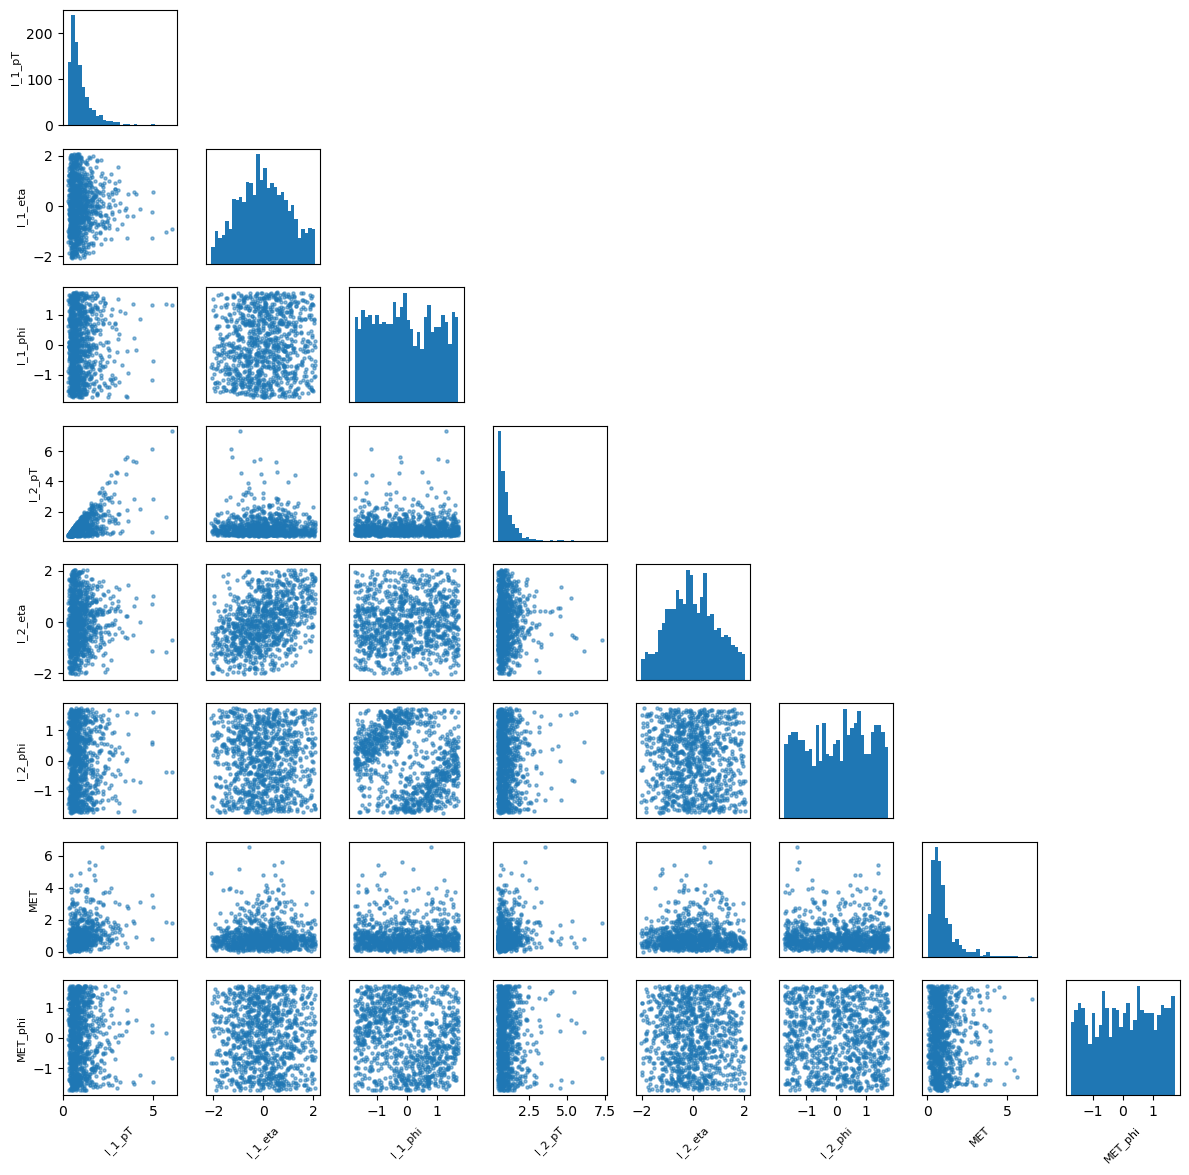

In [18]:
# Making new pair plots for low-level (raw) features
pair_plot_new(df, RawNames)

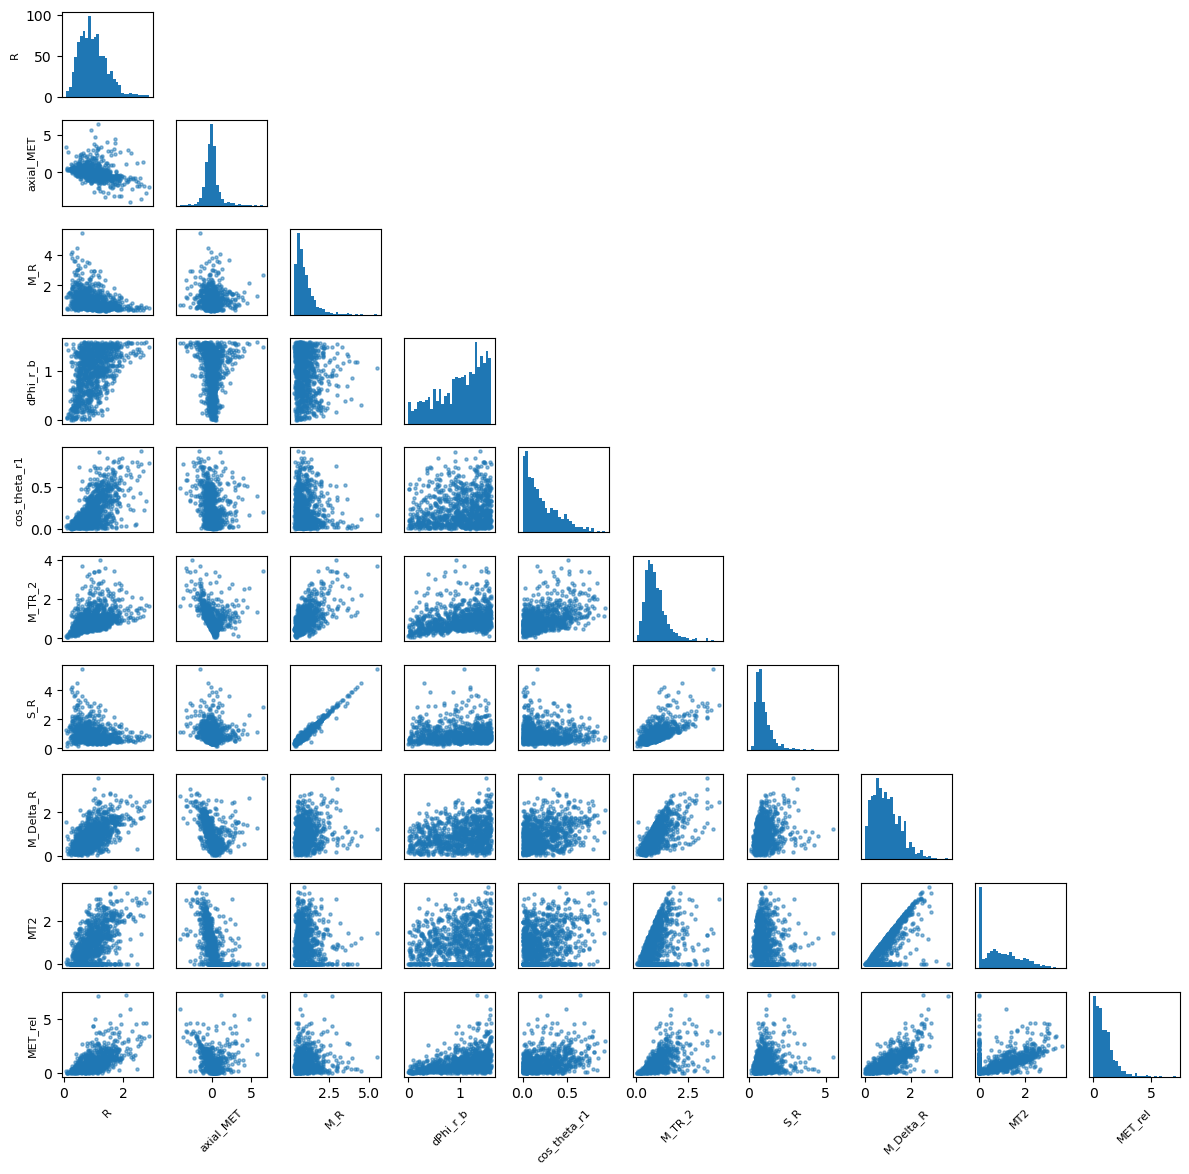

In [19]:
# Make new pair plots for high-level (derived) features
pair_plot_new(df, FeatureNames)

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

Hint: Example code for embedding a `tabulate` table into a notebook:

In [15]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


In [27]:
#Part b
all_data = df[VarNames[1:]]  

# Low-level features
low_data = df[RawNames]

# High-level features
high_data = df[FeatureNames]

#Convert to numpy

all_np = all_data.to_numpy()
low_np = low_data.to_numpy()
high_np = high_data.to_numpy()

#Compute matrices

# ALL VARIABLES 
cov_all = np.cov(all_np.T)
corr_all = np.corrcoef(all_np.T)

# LOW-LEVEL
cov_low = np.cov(low_np.T)
corr_low = np.corrcoef(low_np.T)

# HIGH-LEVEL
cov_high = np.cov(high_np.T)
corr_high = np.corrcoef(high_np.T)

#Print results

print("Covariance matrix (All):")
print(cov_all)

print("Correlation matrix (All):")
print(corr_all)

print("Covariance matrix (Low-level):")
print(cov_low)

print("Correlation matrix (Low-level):")
print(corr_low)

print("Covariance matrix (High-level):")
print(cov_high)

print("Correlation matrix (High-level):")
print(corr_high)


Covariance matrix (All):
[[ 4.67481925e-01 -3.96674207e-04  7.66214265e-05  3.05037988e-01
  -3.48826988e-04  7.37336647e-04  2.28434336e-01 -9.36714374e-04
   9.75240349e-02 -9.73253567e-03  3.64432455e-01  2.87223483e-01
  -5.97024601e-02 -1.23988205e-02  3.42587023e-01  9.77389248e-02
  -4.69491360e-02  2.21632465e-02]
 [-3.96674207e-04  1.00430144e+00 -8.57630732e-04 -1.62905654e-04
   4.08312894e-01 -1.04201049e-03 -2.14697798e-03 -5.88968323e-04
  -1.37057212e-03 -1.10889241e-03 -5.53826632e-04 -6.68920291e-04
   3.01299870e-04  4.27122683e-04 -6.04009571e-04 -9.87471350e-04
  -7.40330277e-04  3.21632240e-04]
 [ 7.66214265e-05 -8.57630732e-04  1.00397336e+00  1.31296001e-03
   2.50714928e-04 -2.66810178e-01  7.66365893e-04 -1.84803977e-01
   7.06206018e-04 -1.87269105e-03  1.06306621e-03  8.68782730e-04
   2.01595554e-04  1.06029189e-03  1.46376567e-03  9.01233064e-04
   9.94305740e-04  2.59098396e-04]
 [ 3.05037988e-01 -1.62905654e-04  1.31296001e-03  4.25490163e-01
  -5.7557138

In [43]:
#Part C
from tabulate import tabulate

In [44]:
def make_table(matrix, row_labels, col_labels, title=""):
    #Convert a numpy matrix into a nicely formatted table using tabulate.
    
    # Round numbers to 3 decimal places (nice and clean)
    rounded = [[round(val, 3) for val in row] for row in matrix]
    
    # Add row labels (first column)
    table = []
    for i in range(len(rounded)):
        table.append([row_labels[i]] + rounded[i])
    
    # Add header (column names)
    headers = ["Variable"] + col_labels
    
    print("\n" + title)
    print(tabulate(table, headers=headers, tablefmt="grid"))

In [46]:
#All variables
make_table(cov_all, VarNames[1:], VarNames[1:], title="Covariance Matrix (All Variables)")
make_table(corr_all, VarNames[1:], VarNames[1:], title="Correlation Matrix (All Variables)")


Covariance Matrix (All Variables)
+--------------+----------+-----------+-----------+----------+-----------+-----------+--------+-----------+-----------+-------------+--------+----------+--------+--------+--------+-------------+------------+----------------+
| Variable     |   l_1_pT |   l_1_eta |   l_1_phi |   l_2_pT |   l_2_eta |   l_2_phi |    MET |   MET_phi |   MET_rel |   axial_MET |    M_R |   M_TR_2 |      R |    MT2 |    S_R |   M_Delta_R |   dPhi_r_b |   cos_theta_r1 |
+==============+==========+===========+===========+==========+===========+===========+========+===========+===========+=============+========+==========+========+========+========+=============+============+================+
| l_1_pT       |    0.467 |    -0     |     0     |    0.305 |    -0     |     0.001 |  0.228 |    -0.001 |     0.098 |      -0.01  |  0.364 |    0.287 | -0.06  | -0.012 |  0.343 |       0.098 |     -0.047 |          0.022 |
+--------------+----------+-----------+-----------+----------+---

In [47]:
#Low-level features
make_table(cov_low, RawNames, RawNames, title="Covariance Matrix (Low-Level)")
make_table(corr_low, RawNames, RawNames, title="Correlation Matrix (Low-Level)")


Covariance Matrix (Low-Level)
+------------+----------+-----------+-----------+----------+-----------+-----------+--------+-----------+
| Variable   |   l_1_pT |   l_1_eta |   l_1_phi |   l_2_pT |   l_2_eta |   l_2_phi |    MET |   MET_phi |
+============+==========+===========+===========+==========+===========+===========+========+===========+
| l_1_pT     |    0.467 |    -0     |     0     |    0.305 |    -0     |     0.001 |  0.228 |    -0.001 |
+------------+----------+-----------+-----------+----------+-----------+-----------+--------+-----------+
| l_1_eta    |   -0     |     1.004 |    -0.001 |   -0     |     0.408 |    -0.001 | -0.002 |    -0.001 |
+------------+----------+-----------+-----------+----------+-----------+-----------+--------+-----------+
| l_1_phi    |    0     |    -0.001 |     1.004 |    0.001 |     0     |    -0.267 |  0.001 |    -0.185 |
+------------+----------+-----------+-----------+----------+-----------+-----------+--------+-----------+
| l_2_pT     | 

In [49]:
#High-level features
make_table(cov_high, FeatureNames, FeatureNames, title="Covariance Matrix (High-Level)")
make_table(corr_high, FeatureNames, FeatureNames, title="Correlation Matrix (High-Level)")


Covariance Matrix (High-Level)
+--------------+--------+-------------+--------+------------+----------------+----------+--------+-------------+--------+-----------+
| Variable     |      R |   axial_MET |    M_R |   dPhi_r_b |   cos_theta_r1 |   M_TR_2 |    S_R |   M_Delta_R |    MT2 |   MET_rel |
+==============+========+=============+========+============+================+==========+========+=============+========+===========+
| R            |  0.222 |      -0.181 | -0.113 |      0.087 |          0.058 |    0.104 | -0.083 |       0.165 |  0.232 |     0.249 |
+--------------+--------+-------------+--------+------------+----------------+----------+--------+-------------+--------+-----------+
| axial_MET    | -0.181 |       1.005 |  0.017 |     -0.025 |         -0.054 |   -0.185 | -0.041 |      -0.233 | -0.461 |    -0.12  |
+--------------+--------+-------------+--------+------------+----------------+----------+--------+-------------+--------+-----------+
| M_R          | -0.113 |     

In [53]:
#Part d:combining b and c
def analyze_dataset(df, VarNames, RawNames, FeatureNames):
    #Part b: select data 
    
    # All features except the first column (usually ID)
    all_data = df[VarNames[1:]]
    # Low-level features
    low_data = df[RawNames]
    # High-level features
    high_data = df[FeatureNames]
    
    # Convert to numpy arrays
    all_np = all_data.to_numpy()
    low_np = low_data.to_numpy()
    high_np = high_data.to_numpy()
    
    # Compute covariance and correlation matrices
    cov_all = np.cov(all_np.T)
    corr_all = np.corrcoef(all_np.T)
    
    cov_low = np.cov(low_np.T)
    corr_low = np.corrcoef(low_np.T)
    
    cov_high = np.cov(high_np.T)
    corr_high = np.corrcoef(high_np.T)
    
    # Part c: helper function for table
    def make_table(matrix, row_labels, col_labels, title=""):
        # Round values to 3 decimals
        rounded = [[round(val, 3) for val in row] for row in matrix]
        # Add row labels
        table = [[row_labels[i]] + rounded[i] for i in range(len(rounded))]
        # Add header
        headers = ["Variable"] + col_labels
        # Print table
        print("\n" + title)
        print(tabulate(table, headers=headers, tablefmt="grid"))
    
    #Print all tables
    make_table(cov_all, VarNames[1:], VarNames[1:], "Covariance Matrix (All Variables)")
    make_table(corr_all, VarNames[1:], VarNames[1:], "Correlation Matrix (All Variables)")
    
    make_table(cov_low, RawNames, RawNames, "Covariance Matrix (Low-level Features)")
    make_table(corr_low, RawNames, RawNames, "Correlation Matrix (Low-level Features)")
    
    make_table(cov_high, FeatureNames, FeatureNames, "Covariance Matrix (High-level Features)")
    make_table(corr_high, FeatureNames, FeatureNames, "Correlation Matrix (High-level Features)")

In [52]:
analyze_dataset(df, VarNames, RawNames, FeatureNames)


Covariance Matrix (All Variables)
+--------------+----------+-----------+-----------+----------+-----------+-----------+--------+-----------+-----------+-------------+--------+----------+--------+--------+--------+-------------+------------+----------------+
| Variable     |   l_1_pT |   l_1_eta |   l_1_phi |   l_2_pT |   l_2_eta |   l_2_phi |    MET |   MET_phi |   MET_rel |   axial_MET |    M_R |   M_TR_2 |      R |    MT2 |    S_R |   M_Delta_R |   dPhi_r_b |   cos_theta_r1 |
+==============+==========+===========+===========+==========+===========+===========+========+===========+===========+=============+========+==========+========+========+========+=============+============+================+
| l_1_pT       |    0.467 |    -0     |     0     |    0.305 |    -0     |     0.001 |  0.228 |    -0.001 |     0.098 |      -0.01  |  0.364 |    0.287 | -0.06  | -0.012 |  0.343 |       0.098 |     -0.047 |          0.022 |
+--------------+----------+-----------+-----------+----------+---